# Hello world — astro-inject

This notebook is the visual sanity check for the scaffolding. It does four things:

1. Imports `astro_inject` and prints the version.
2. Synthesizes a small noisy 512×512 image with a few Gaussian sources.
3. Wraps it as a `CCDData` with a minimal TAN WCS.
4. Renders it inline with `astro_inject.viz.plot_image()` (asinh stretch + percentile interval).

If you can see a recognisably astronomical-looking image at the bottom of the notebook, the plumbing works.

In [2]:
%pip install matplotlib
%pip install astropy

Note: you may need to restart the kernel to use updated packages.
  Using cached pyerfa-2.0.1.5-cp39-abi3-macosx_11_0_arm64.whl.metadata (5.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 10.6 MB/s  0:00:000.8 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 10.2 MB/s  0:00:00
Using cached pyerfa-2.0.1.5-cp39-abi3-macosx_11_0_arm64.whl (329 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [astropy]━━━━━━━━━━ 2/3 [astropy]
Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.nddata import CCDData
from astropy.wcs import WCS

import astro_inject
from astro_inject.viz import plot_image

print(f"astro_inject {astro_inject.__version__}")

ModuleNotFoundError: No module named 'astro_inject'

## Synthesize a small frame

Gaussian background + a handful of Gaussian point sources at random positions. Reproducible via the explicit `np.random.default_rng` seed.

In [2]:
rng = np.random.default_rng(seed=2026)
shape = (512, 512)

background = rng.normal(loc=100.0, scale=5.0, size=shape).astype(np.float32)

n_sources = 40
ys = rng.uniform(0, shape[0], size=n_sources)
xs = rng.uniform(0, shape[1], size=n_sources)
amps = rng.lognormal(mean=5.5, sigma=0.7, size=n_sources)
sigmas = rng.uniform(1.5, 2.5, size=n_sources)

yy, xx = np.mgrid[: shape[0], : shape[1]]
image_data = background.copy()
for y0, x0, amp, sigma in zip(ys, xs, amps, sigmas, strict=True):
    image_data += (amp * np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))).astype(
        np.float32
    )

image_data.shape, image_data.dtype, float(image_data.min()), float(image_data.max())

((512, 512), dtype('float32'), 78.06094360351562, 1738.9112548828125)

## Wrap as `CCDData` with a minimal WCS

In [3]:
wcs = WCS(naxis=2)
wcs.wcs.crpix = [shape[1] / 2, shape[0] / 2]
wcs.wcs.crval = [10.0, -20.0]
wcs.wcs.cdelt = [-0.0001, 0.0001]
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]

image = CCDData(image_data, unit="adu", wcs=wcs)
image

CCDData([[ 96.034386, 101.20286 ,  90.51837 , ..., 104.63928 ,
          101.57985 , 116.18116 ],
         [102.67625 , 100.16246 , 103.052605, ...,  98.15883 ,
          104.94554 , 107.45968 ],
         [107.56105 , 103.411446, 101.802895, ...,  94.702515,
           96.37679 , 101.76601 ],
         ...,
         [101.0741  , 105.40142 ,  94.28811 , ..., 102.52209 ,
          102.32768 ,  97.34434 ],
         [ 91.34036 , 101.94091 ,  95.54686 , ...,  93.244125,
           96.8592  , 102.69417 ],
         [ 96.30994 ,  95.79615 , 104.43542 , ...,  97.5484  ,
          103.21506 ,  98.25658 ]], shape=(512, 512), dtype=float32, unit='adu')

## Render with `plot_image`

This is the only "real" piece of functionality in the current scaffold — an asinh stretch plus a percentile interval, which is the standard astronomy-friendly default.

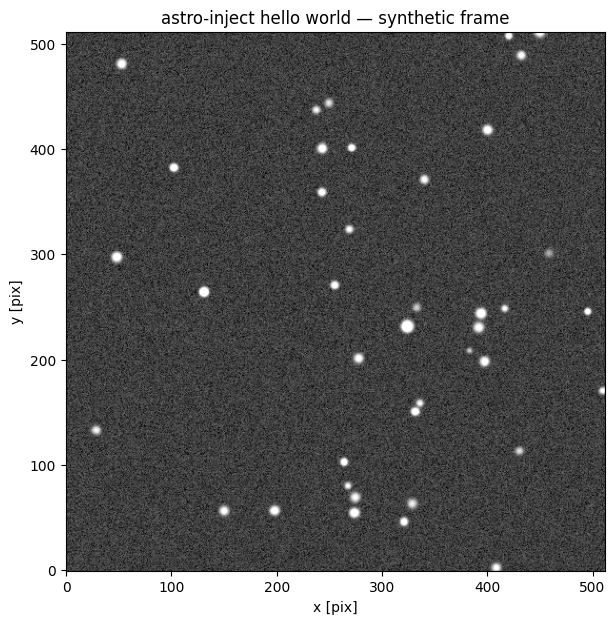

In [4]:
fig, ax = plt.subplots(figsize=(7, 7))
plot_image(image, ax=ax, percentile=99.5)
ax.set_title("astro-inject hello world — synthetic frame")
plt.show()

## What just happened?

* We exercised the full import path of the package.
* We confirmed `CCDData`, WCS, and matplotlib all play together as expected.
* We verified that `plot_image` produces a recognisably astronomical-looking render.

## What's next?

Real injection physics is intentionally **not** implemented yet. The next milestones are:

1. Fill in `astro_inject.trails.TrailParameters` with real geometry and a brightness profile.
2. Implement `astro_inject.composition.inject(...)` so it returns a populated `InjectionResult`.
3. Add the first concrete `Instrument` descriptors and validate against real frames.

Until then, this notebook is the smoke test that the scaffolding is solid.